# Home Loan Default Prediction using Deep Learning

## Project Overview
Solve the Home Loan Data Analysis project.

### Objective
Predict whether a loan applicant is likely to default using historical data.

### Workflow
1. Load data
2. Data quality checks
3. Exploratory analysis
4. Handle class imbalance
5. Encode categorical variables
6. Train deep learning model
7. Evaluate using Sensitivity and ROC-AUC
8. Conclusions

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix,roc_auc_score,roc_curve
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

## Load Dataset

In [2]:
df=pd.read_csv('loan_data.csv')
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Check Missing Values

In [3]:
missing=df.isnull().sum()
missing=missing[missing>0].sort_values(ascending=False)
print(missing.head(20))

COMMONAREA_MEDI             214865
COMMONAREA_MODE             214865
COMMONAREA_AVG              214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MEDI              208642
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64


## Default Percentage

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


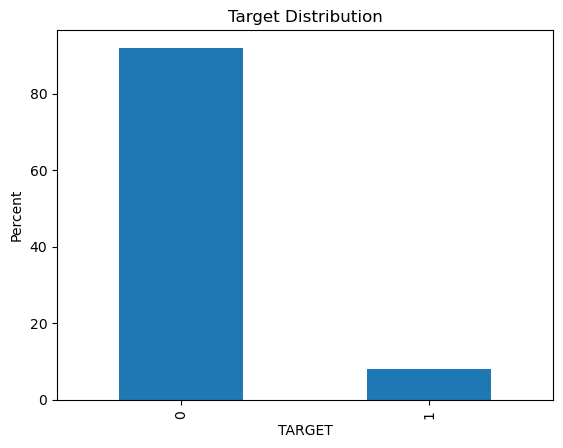

In [4]:
target_pct=df['TARGET'].value_counts(normalize=True)*100
print(target_pct)
target_pct.plot(kind='bar')
plt.title('Target Distribution')
plt.ylabel('Percent')
plt.show()

## Balance Dataset

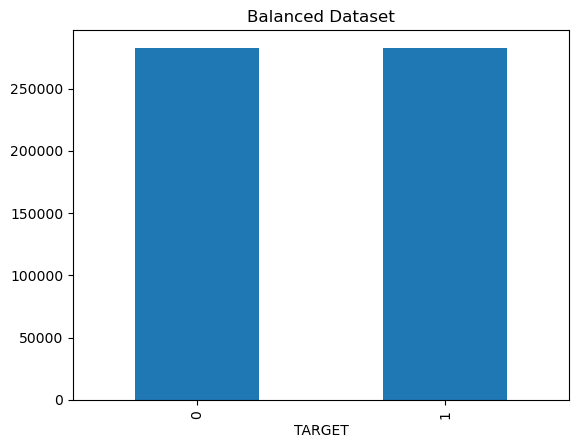

TARGET
0    282686
1    282686
Name: count, dtype: int64

In [5]:
major=df[df.TARGET==0]
minor=df[df.TARGET==1]
minor_up=resample(minor,replace=True,n_samples=len(major),random_state=42)
balanced=pd.concat([major,minor_up])
balanced['TARGET'].value_counts().plot(kind='bar')
plt.title('Balanced Dataset')
plt.show()
balanced=balanced.sample(frac=1,random_state=42)
balanced['TARGET'].value_counts()

## Data Preprocessing

In [6]:
X=balanced.drop('TARGET',axis=1)
y=balanced['TARGET']

cat=X.select_dtypes(include='object').columns
num=X.select_dtypes(exclude='object').columns

for c in cat:
    X[c]=X[c].astype(str)
    X[c]=LabelEncoder().fit_transform(X[c])

X[num]=SimpleImputer(strategy='median').fit_transform(X[num])
scaler=StandardScaler()
X[num]=scaler.fit_transform(X[num])

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape,X_test.shape)


(452297, 121) (113075, 121)


## Build Deep Learning Model

In [11]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early = EarlyStopping(
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early]
)

Epoch 1/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6448 - loss: 0.6341 - val_accuracy: 0.6795 - val_loss: 0.5996
Epoch 2/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6787 - loss: 0.6011 - val_accuracy: 0.6838 - val_loss: 0.5962
Epoch 3/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6827 - loss: 0.5954 - val_accuracy: 0.6860 - val_loss: 0.5912
Epoch 4/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6860 - loss: 0.5908 - val_accuracy: 0.6900 - val_loss: 0.5859
Epoch 5/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6890 - loss: 0.5858 - val_accuracy: 0.6919 - val_loss: 0.5814
Epoch 6/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6929 - loss: 0.5814 - val_accuracy: 0.6962 - val_loss: 0.5767
Epoch 7/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6952 - loss: 0.5774 - val_accuracy: 0.7002 - val_loss: 0.5726
Epoch 8/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6976 - loss: 0.5733 - val_accuracy: 0.

## Model Evaluation

3534/3534 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
[[39171 17546]
 [15178 41180]]
Sensitivity: 0.7306859718229888
ROC AUC: 0.7836733162915758


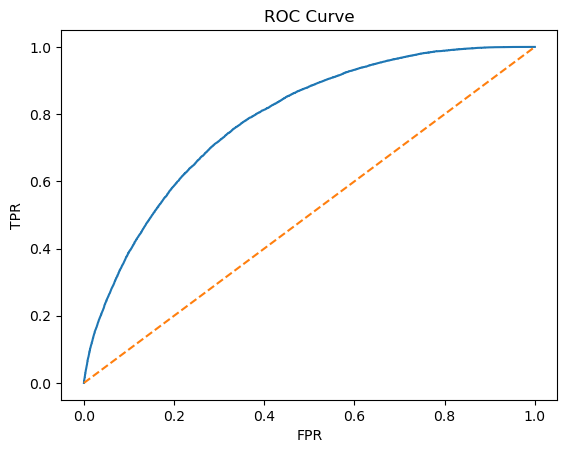

In [12]:
pred_prob=model.predict(X_test).ravel()
pred=(pred_prob>0.5).astype(int)
cm=confusion_matrix(y_test,pred)
tn,fp,fn,tp=cm.ravel()
sensitivity=tp/(tp+fn)
auc=roc_auc_score(y_test,pred_prob)
print(cm)
print("Sensitivity:",sensitivity)
print("ROC AUC:",auc)

fpr,tpr,_=roc_curve(y_test,pred_prob)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()


## Conclusions

- Checked missing values.
- Computed default percentage.
- Balanced the imbalanced dataset.
- Encoded categorical variables.
- Built a TensorFlow deep learning classifier.
- Calculated Sensitivity.
- Calculated ROC-AUC.
- Generated ROC curve.